# Feature Engineering for Health Risk Prediction
This notebook prepares advanced features for machine learning models.


In [8]:
df = pd.read_csv("../data/city_day_cleaned.csv", parse_dates=["datetime"])

print(df.shape)
df.head()


(29531, 16)


,datetime,city,aqi,pm25,pm10,no,no2,nox,nh3,co,so2,o3,benzene,toluene,xylene,risk
0,2015-01-01,Ahmedabad,NaN,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN
1,2015-01-02,Ahmedabad,NaN,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN
2,2015-01-03,Ahmedabad,NaN,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN
3,2015-01-04,Ahmedabad,NaN,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN
4,2015-01-05,Ahmedabad,NaN,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os

print("✅ All libraries imported")

✅ All libraries imported


In [10]:
print(df.shape)


(29531, 16)


In [11]:
df.head(10)


,datetime,city,aqi,pm25,pm10,no,no2,nox,nh3,co,so2,o3,benzene,toluene,xylene,risk
0,2015-01-01,Ahmedabad,NaN,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN
1,2015-01-02,Ahmedabad,NaN,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN
2,2015-01-03,Ahmedabad,NaN,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN
3,2015-01-04,Ahmedabad,NaN,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN
4,2015-01-05,Ahmedabad,NaN,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN
5,2015-01-06,Ahmedabad,NaN,NaN,NaN,45.41,38.48,81.50,NaN,45.41,45.76,46.51,5.42,10.83,1.93,NaN
6,2015-01-07,Ahmedabad,NaN,NaN,NaN,112.16,40.62,130.77,NaN,112.16,32.28,33.47,0.00,0.00,0.00,NaN
7,2015-01-08,Ahmedabad,NaN,NaN,NaN,80.87,36.74,96.75,NaN,80.87,38.54,31.89,0.00,0.00,0.00,NaN
8,2015-01-09,Ahmedabad,NaN,NaN,NaN,29.16,31.00,48.00,NaN,29.16,58.68,25.75,0.00,0.00,0.00,NaN
9,2015-01-10,Ahmedabad,NaN,NaN,NaN,29.16,7.04,0.00,NaN,29.16,8.29,4.55,0.00,0.00,0.00,NaN


In [12]:
df.tail()


,datetime,city,aqi,pm25,pm10,no,no2,nox,nh3,co,so2,o3,benzene,toluene,xylene,risk
29526,2020-06-27,Visakhapatnam,41.0,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,Low
29527,2020-06-28,Visakhapatnam,70.0,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,Low
29528,2020-06-29,Visakhapatnam,68.0,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,Low
29529,2020-06-30,Visakhapatnam,54.0,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,Low
29530,2020-07-01,Visakhapatnam,50.0,15.00,66.00,0.40,26.85,14.05,5.20,0.59,2.10,17.05,0.00,0.00,0.00,Low


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["city_encoded"] = le.fit_transform(df["city"])

df[["city", "city_encoded"]].head()


,city,city_encoded
0,Ahmedabad,0
1,Ahmedabad,0
2,Ahmedabad,0
3,Ahmedabad,0
4,Ahmedabad,0


In [ ]:
split_ratio = 0.8
split_index = int(len(df) * split_ratio)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


In [ ]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_base))


Baseline Accuracy: 0.9962880475129918

Classification Report:

              precision    recall  f1-score   support

        High       0.98      1.00      0.99       102
         Low       1.00      1.00      1.00       549
    Moderate       1.00      0.99      1.00       696

    accuracy                           1.00      1347
   macro avg       0.99      1.00      0.99      1347
weighted avg       1.00      1.00      1.00      1347



c:\SRP_PROJECT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       102
         Low       1.00      1.00      1.00       549
    Moderate       1.00      1.00      1.00       696

    accuracy                           1.00      1347
   macro avg       1.00      1.00      1.00      1347
weighted avg       1.00      1.00      1.00      1347



In [ ]:
X_train_clean = X_clean.iloc[:split_index]
X_test_clean = X_clean.iloc[split_index:]

print(X_train_clean.shape, X_test_clean.shape)


(5384, 22) (1347, 22)


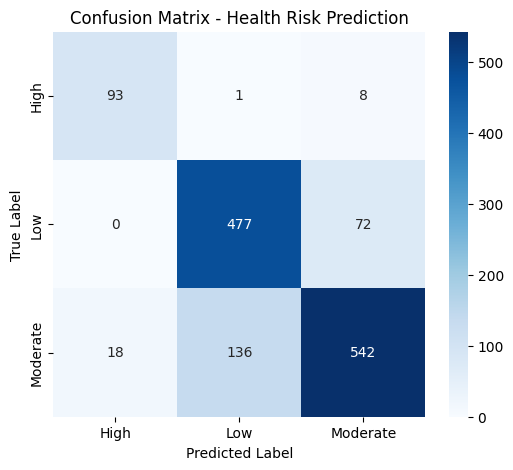

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_clean)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["High", "Low", "Moderate"],
            yticklabels=["High", "Low", "Moderate"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Health Risk Prediction")
plt.show()


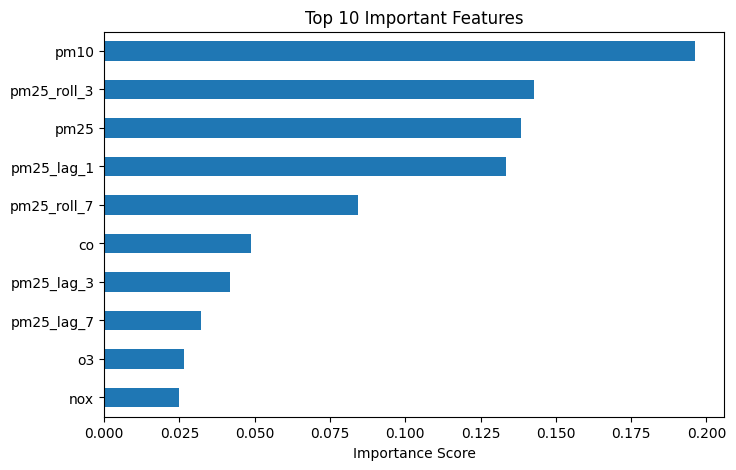

In [ ]:
plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind="barh")
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()


c:\SRP_PROJECT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


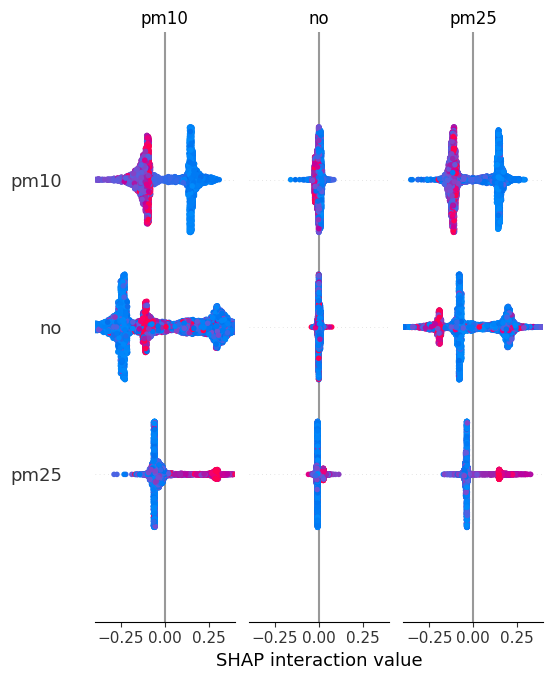

In [ ]:
import shap

explainer = shap.TreeExplainer(rf_clean)
shap_values = explainer.shap_values(X_train_clean)
shap.summary_plot(shap_values, X_train_clean)


In [ ]:
X_train_clean.columns.tolist()


['pm25',
 'pm10',
 'no',
 'no2',
 'nox',
 'nh3',
 'co',
 'so2',
 'o3',
 'benzene',
 'toluene',
 'xylene',
 'year',
 'month',
 'day',
 'day_of_week',
 'pm25_lag_1',
 'pm25_lag_3',
 'pm25_lag_7',
 'pm25_roll_3',
 'pm25_roll_7',
 'city_encoded']

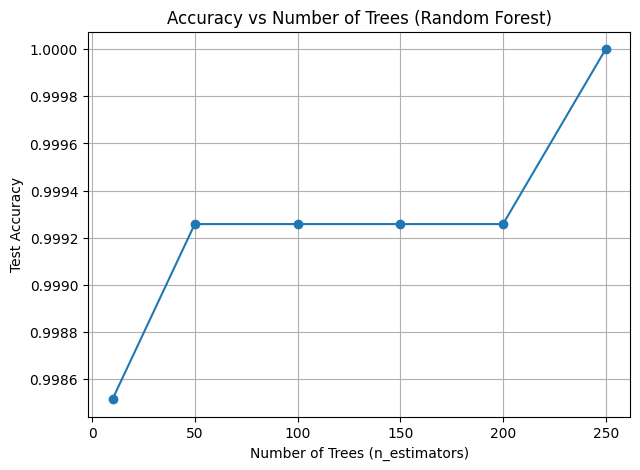

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

estimators = [10, 50, 100, 150, 200, 250]
accuracy_scores = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracy_scores.append(acc)

plt.figure(figsize=(7,5))
plt.plot(estimators, accuracy_scores, marker='o')
plt.title("Accuracy vs Number of Trees (Random Forest)")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()

In [ ]:
print(X.columns.tolist())

In [16]:
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)

print("\n1. DATASET SHAPE:")
print(df.shape)

print("\n2. COLUMNS:")
print(df.columns.tolist())

print("\n3. DATA TYPES:")
print(df.dtypes)

print("\n4. MISSING VALUES:")
print(df.isnull().sum())

print("\n5. TARGET VARIABLE DISTRIBUTION:")
print(df['Health_Risk'].value_counts())

print("\n6. BASIC STATISTICS:")
print(df.describe())

print("\n7. UNIQUE CITIES:")
print(df['City'].nunique())
print(df['City'].unique())

print("\n8. AQI RANGE:")
print("Min AQI:", df['AQI'].min())
print("Max AQI:", df['AQI'].max())
print("Mean AQI:", df['AQI'].mean())

print("\n9. ALL COLUMN VALUES SAMPLE:")
print(df.head(3))

EDA SUMMARY

1. DATASET SHAPE:
(29531, 17)

2. COLUMNS:
['datetime', 'city', 'aqi', 'pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3', 'benzene', 'toluene', 'xylene', 'risk', 'city_encoded']

3. DATA TYPES:
datetime        datetime64[ns]
city                    object
aqi                    float64
pm25                   float64
pm10                   float64
no                     float64
no2                    float64
nox                    float64
nh3                    float64
co                     float64
so2                    float64
o3                     float64
benzene                float64
toluene                float64
xylene                 float64
risk                    object
city_encoded             int64
dtype: object

4. MISSING VALUES:
datetime            0
city                0
aqi              3486
pm25             3869
pm10            10368
no               2734
no2              2739
nox              3619
nh3              9574
co               1238
s

KeyError: 'Health_Risk'

In [18]:
X = df.drop(columns=['aqi', 'risk', 'datetime', 'city'])
y = df['risk']

print("✅ Features used (NO leakage):")
print(X.columns.tolist())
print("\nShape:", X.shape)
print("Classes:", y.unique())

✅ Features used (NO leakage):
['pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3', 'benzene', 'toluene', 'xylene', 'city_encoded']

Shape: (29531, 13)
Classes: [nan 'High' 'Moderate' 'Low']


In [19]:
X = X.fillna(X.median())
print("Missing values after fill:", X.isnull().sum().sum())

Missing values after fill: 0


In [20]:
mask = y.notna()
X = X[mask]
y = y[mask]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y distribution:\n", y.value_counts())

X shape: (26045, 13)
y shape: (26045,)
y distribution:
 risk
Low         10052
Moderate     9235
High         6758
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, lr.predict(X_test)))
print(classification_report(y_test, lr.predict(X_test)))

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("--- Decision Tree ---")
print("Accuracy:", accuracy_score(y_test, dt.predict(X_test)))
print(classification_report(y_test, dt.predict(X_test)))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("--- Random Forest ---")
print("Accuracy:", accuracy_score(y_test, rf.predict(X_test)))
print(classification_report(y_test, rf.predict(X_test)))

c:\SRP_PROJECT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Logistic Regression ---
Accuracy: 0.8362449606450374
              precision    recall  f1-score   support

        High       0.92      0.85      0.88      1339
         Low       0.87      0.86      0.86      2072
    Moderate       0.75      0.80      0.77      1798

    accuracy                           0.84      5209
   macro avg       0.85      0.84      0.84      5209
weighted avg       0.84      0.84      0.84      5209

--- Decision Tree ---
Accuracy: 0.8193511230562488
              precision    recall  f1-score   support

        High       0.86      0.88      0.87      1339
         Low       0.86      0.84      0.85      2072
    Moderate       0.74      0.75      0.75      1798

    accuracy                           0.82      5209
   macro avg       0.82      0.82      0.82      5209
weighted avg       0.82      0.82      0.82      5209

--- Random Forest ---
Accuracy: 0.8775196774812823
              precision    recall  f1-score   support

        High       0.92 

In [22]:
print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"Logistic Regression : {accuracy_score(y_test, lr.predict(X_test)):.4f}")
print(f"Decision Tree       : {accuracy_score(y_test, dt.predict(X_test)):.4f}")
print(f"Random Forest       : {accuracy_score(y_test, rf.predict(X_test)):.4f}")
print("=" * 50)
print("BEST MODEL: Random Forest ✅")

MODEL COMPARISON SUMMARY
Logistic Regression : 0.8362
Decision Tree       : 0.8194
Random Forest       : 0.8775
BEST MODEL: Random Forest ✅


In [23]:
import joblib
import os

model_path = os.path.join('..', 'models', 'health_risk_rf_model.pkl')
joblib.dump(rf, model_path)
print("Model saved to:", model_path)

Model saved to: ..\models\health_risk_rf_model.pkl


In [24]:
# Sort by city and datetime — required for lag features
df = df.sort_values(['city', 'datetime']).reset_index(drop=True)

# Lag features
df['pm25_lag_1'] = df.groupby('city')['pm25'].shift(1)
df['pm25_lag_3'] = df.groupby('city')['pm25'].shift(3)
df['pm25_lag_7'] = df.groupby('city')['pm25'].shift(7)

# Rolling features
df['pm25_roll_3'] = df.groupby('city')['pm25'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
df['pm25_roll_7'] = df.groupby('city')['pm25'].transform(
    lambda x: x.shift(1).rolling(7).mean()
)

# Time features
df['year']        = df['datetime'].dt.year
df['month']       = df['datetime'].dt.month
df['day']         = df['datetime'].dt.day
df['day_of_week'] = df['datetime'].dt.dayofweek

print("✅ All features created")
print(df.columns.tolist())

✅ All features created
['datetime', 'city', 'aqi', 'pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3', 'benzene', 'toluene', 'xylene', 'risk', 'city_encoded', 'pm25_lag_1', 'pm25_lag_3', 'pm25_lag_7', 'pm25_roll_3', 'pm25_roll_7', 'year', 'month', 'day', 'day_of_week']


In [25]:
X = df.drop(columns=['aqi', 'risk', 'datetime', 'city'])
y = df['risk']

X = X.fillna(X.median())

mask = y.notna()
X = X[mask]
y = y[mask]

print("✅ Features:", X.columns.tolist())
print("Total features:", len(X.columns))
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

✅ Features: ['pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3', 'benzene', 'toluene', 'xylene', 'city_encoded', 'pm25_lag_1', 'pm25_lag_3', 'pm25_lag_7', 'pm25_roll_3', 'pm25_roll_7', 'year', 'month', 'day', 'day_of_week']
Total features: 22
X shape: (26045, 22)
y distribution:
 risk
Low         10052
Moderate     9235
High         6758
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os

print("✅ Libraries imported")

✅ Libraries imported


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Train size:", X_train.shape)
print("✅ Test size:", X_test.shape)

✅ Train size: (20836, 22)
✅ Test size: (5209, 22)


In [28]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train, y_train)
print("--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, lr.predict(X_test)))
print(classification_report(y_test, lr.predict(X_test)))

--- Logistic Regression ---
Accuracy: 0.8575542330581686
              precision    recall  f1-score   support

        High       0.93      0.88      0.91      1339
         Low       0.88      0.88      0.88      2072
    Moderate       0.78      0.82      0.80      1798

    accuracy                           0.86      5209
   macro avg       0.87      0.86      0.86      5209
weighted avg       0.86      0.86      0.86      5209



c:\SRP_PROJECT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("--- Decision Tree ---")
print("Accuracy:", accuracy_score(y_test, dt.predict(X_test)))
print(classification_report(y_test, dt.predict(X_test)))

--- Decision Tree ---
Accuracy: 0.8456517565751583
              precision    recall  f1-score   support

        High       0.91      0.90      0.90      1339
         Low       0.87      0.86      0.87      2072
    Moderate       0.78      0.79      0.78      1798

    accuracy                           0.85      5209
   macro avg       0.85      0.85      0.85      5209
weighted avg       0.85      0.85      0.85      5209



In [30]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("--- Random Forest ---")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

--- Random Forest ---
Accuracy: 0.8963332693415242
              precision    recall  f1-score   support

        High       0.94      0.93      0.93      1339
         Low       0.92      0.90      0.91      2072
    Moderate       0.84      0.87      0.85      1798

    accuracy                           0.90      5209
   macro avg       0.90      0.90      0.90      5209
weighted avg       0.90      0.90      0.90      5209



In [31]:
print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"Logistic Regression : {accuracy_score(y_test, lr.predict(X_test)):.4f}")
print(f"Decision Tree       : {accuracy_score(y_test, dt.predict(X_test)):.4f}")
print(f"Random Forest       : {accuracy_score(y_test, rf.predict(X_test)):.4f}")
print("=" * 50)
print("BEST MODEL: Random Forest ✅")

MODEL COMPARISON SUMMARY
Logistic Regression : 0.8576
Decision Tree       : 0.8457
Random Forest       : 0.8963
BEST MODEL: Random Forest ✅


In [32]:
import joblib
import os

model_path = os.path.join('..', 'models', 'health_risk_rf_model.pkl')
joblib.dump(rf, model_path)
print("Model saved to:", model_path)

Model saved to: ..\models\health_risk_rf_model.pkl


In [33]:
import os

model_path = os.path.join('..', 'models', 'health_risk_rf_model.pkl')

if os.path.exists(model_path):
    print("✅ Model file EXISTS at:", model_path)
    size = os.path.getsize(model_path)
    print("File size:", round(size / 1024 / 1024, 2), "MB")
else:
    print("❌ Model file NOT found — check the path")

✅ Model file EXISTS at: ..\models\health_risk_rf_model.pkl
File size: 30.2 MB


In [34]:
print("Model expects these features:")
print(rf.feature_names_in_.tolist())
print("\nTotal:", len(rf.feature_names_in_))

Model expects these features:
['pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3', 'benzene', 'toluene', 'xylene', 'city_encoded', 'pm25_lag_1', 'pm25_lag_3', 'pm25_lag_7', 'pm25_roll_3', 'pm25_roll_7', 'year', 'month', 'day', 'day_of_week']

Total: 22


In [ ]:
import pandas as pd
import numpy as np

print("=" * 60)
print("MODEL SUMMARY FOR AIRSEVA AGENT BUILD")
print("=" * 60)

# 1. Exact feature names and count
print(f"\nTotal Features: {len(X_train.columns)}")
print("\nExact Feature Names (copy these exactly):")
print(X_train.columns.tolist())

# 2. Risk label mapping
print("\nRisk Label Mapping:")
print(model.classes_)

# 3. Feature dtypes
print("\nFeature Data Types:")
print(X_train.dtypes)

# 4. Sample values to verify ranges
print("\nFeature Value Ranges (from training data):")
print(X_train.describe().round(2))

# 5. Verify model loaded correctly
print("\nModel Type:", type(model))
print("Number of Trees:", model.n_estimators)

# 6. Quick sanity check prediction
sample = X_train.iloc[[0]]
pred = model.predict(sample)
print("\nSanity Check Prediction on first training row:", pred)
print("Expected (from y_train):", y_train.iloc[0])

print("\n" + "=" * 60)
print("COPY EVERYTHING ABOVE THIS LINE")
print("=" * 60)